In [91]:
# Jupyter notebooks have problems with imports from parent folder, so let's change the path
from jupyter_utils import change_path_to_parent
change_path_to_parent()

import matplotlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
from optmethods.first_order import AdgdAccel
from optmethods.datasets import get_dataset


from optmethods.loss import LogisticRegression, LogSumExp
from optmethods.second_order import Newton
from optmethods.second_order import CaCuAdGD
from optmethods.second_order import Cubic, AccCubic, SuperCubic
from optmethods.second_order import CaCuN, AccCaCuN
from optmethods.second_order import Arc, Cubic, Newton, RegNewton
from optmethods.quasi_newton import Bfgs, Dfp, Lbfgs, Sr1, Shorr
from optmethods.first_order import Adgd, AdgdAccel, Gd, Nesterov, Ogm, Polyak, RestNest, NestLine
from optmethods.utils import get_trace, relative_round

sns.set(style="whitegrid", context="talk", palette=sns.color_palette("bright"), color_codes=False)
matplotlib.rc('font', family='sans-serif') 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.figsize'] = (9, 6)

markers = ['s', 'o', '^', '*', 'v', 'X', '+', 'P', '.', 6, 7]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
l2 = 1e-7
ifl2 = f"_l2_{l2}" if l2 > 0 else ""

In [93]:
dataset = 'covtype'
A, b = get_dataset(dataset)

b = np.asarray(b).ravel()
u = np.unique(b)
if u.size == 2 and set(u) <= {0,1}:
    b = b.astype(np.float64)
else:
 b = (b == 1).astype(np.float64)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# loss.f_opt = 0.4657138629352897 #l2 = 0
# loss.f_opt = 0.46580040590571636 #l2 = 1e-7

Running optimizer: AdGD
CPU times: user 33min 54s, sys: 60 ms, total: 33min 54s
Wall time: 31.8 s
Running optimizer: NesterovLS
CPU times: user 2h 55min 28s, sys: 340 ms, total: 2h 55min 28s
Wall time: 2min 44s
Running optimizer: Polyak
CPU times: user 1h 1min 18s, sys: 120 ms, total: 1h 1min 18s
Wall time: 57.5 s
Running optimizer: CaCuAdGD
CPU times: user 1h 46min 5s, sys: 220 ms, total: 1h 46min 5s
Wall time: 1min 39s


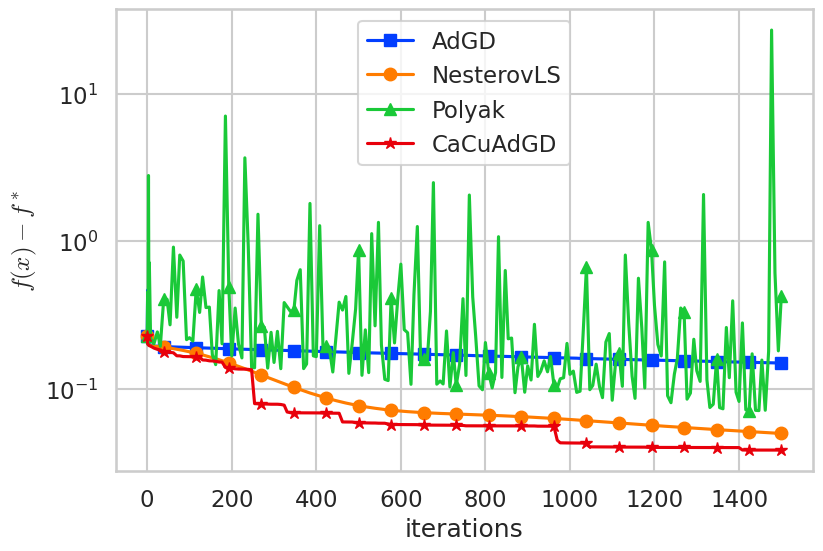

In [94]:
if l2 == 0.:
    loss.f_opt = 0.4657138629352897
elif l2 == 1e-7:
    loss.f_opt = 0.46580040590571636
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
    
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

it_max = 1500
time=False
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

Running optimizer: AdGD
CPU times: user 1h 46min 40s, sys: 210 ms, total: 1h 46min 40s
Wall time: 1min 40s
Running optimizer: NesterovLS
CPU times: user 1h 46min 40s, sys: 200 ms, total: 1h 46min 41s
Wall time: 1min 40s
Running optimizer: Polyak
CPU times: user 1h 46min 40s, sys: 220 ms, total: 1h 46min 41s
Wall time: 1min 40s
Running optimizer: CaCuAdGD
CPU times: user 1h 46min 42s, sys: 240 ms, total: 1h 46min 42s
Wall time: 1min 40s


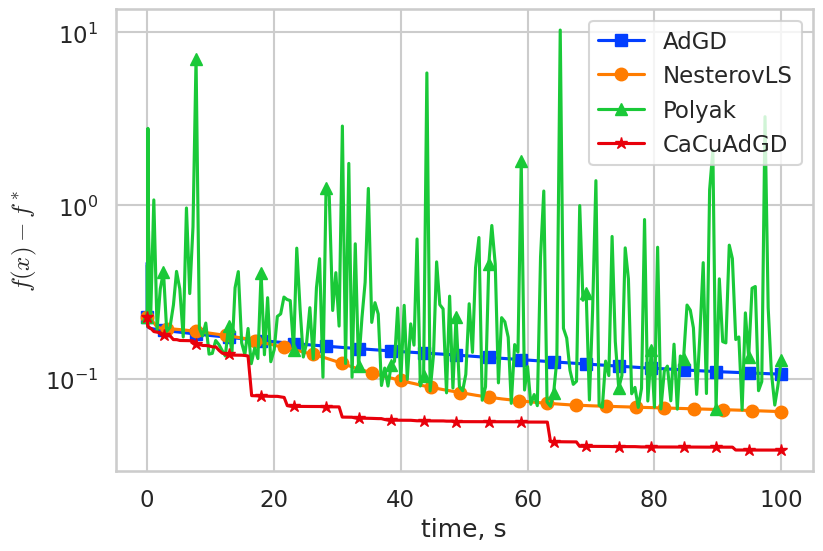

In [95]:
if l2 == 0.:
    loss.f_opt = 0.4657138629352897
elif l2 == 1e-7:
    loss.f_opt = 0.46580040590571636
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=True
t_max = 100
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time, use_ls_its=False)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [96]:
dataset = 'w8a'
A, b = get_dataset(dataset)

n, dim = A.shape
# A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)

The passed labels have values in the set {-1, 1}. Changing them to {0, 1}


fopt=np.float64(0.11081101241317684)
Running optimizer: AdGD
CPU times: user 985 ms, sys: 3 μs, total: 985 ms
Wall time: 984 ms
Running optimizer: NesterovLS
CPU times: user 4.51 s, sys: 1 μs, total: 4.51 s
Wall time: 4.51 s
Running optimizer: Polyak
CPU times: user 1.92 s, sys: 1e+03 ns, total: 1.92 s
Wall time: 1.92 s
Running optimizer: CaCuAdGD
CPU times: user 3.66 s, sys: 0 ns, total: 3.66 s
Wall time: 3.66 s


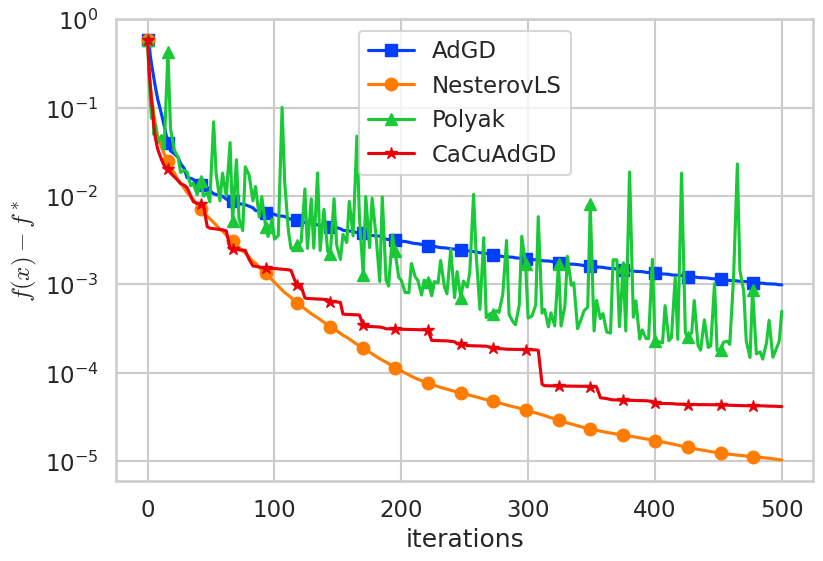

In [97]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(0.11081101241317684)
Running optimizer: AdGD
CPU times: user 20 s, sys: 1e+03 ns, total: 20 s
Wall time: 20 s
Running optimizer: NesterovLS
CPU times: user 20 s, sys: 10 ms, total: 20 s
Wall time: 20 s
Running optimizer: Polyak
CPU times: user 20 s, sys: 1e+03 ns, total: 20 s
Wall time: 20 s
Running optimizer: CaCuAdGD
CPU times: user 20 s, sys: 10 ms, total: 20 s
Wall time: 20 s


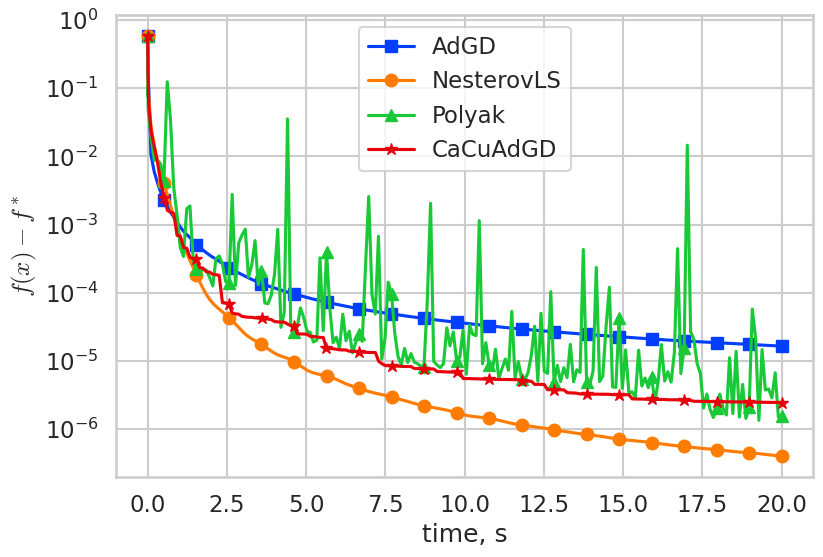

In [98]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=True
t_max = 20
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [99]:
dataset = 'mushrooms'
A, b = get_dataset(dataset)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {1, 2}. Changing them to {0, 1}


fopt=np.float64(2.772122812435447e-18)
Running optimizer: AdGD
CPU times: user 211 ms, sys: 1e+03 ns, total: 211 ms
Wall time: 211 ms
Running optimizer: NesterovLS
CPU times: user 930 ms, sys: 0 ns, total: 930 ms
Wall time: 929 ms
Running optimizer: Polyak
CPU times: user 368 ms, sys: 0 ns, total: 368 ms
Wall time: 368 ms
Running optimizer: CaCuAdGD
CPU times: user 700 ms, sys: 0 ns, total: 700 ms
Wall time: 700 ms


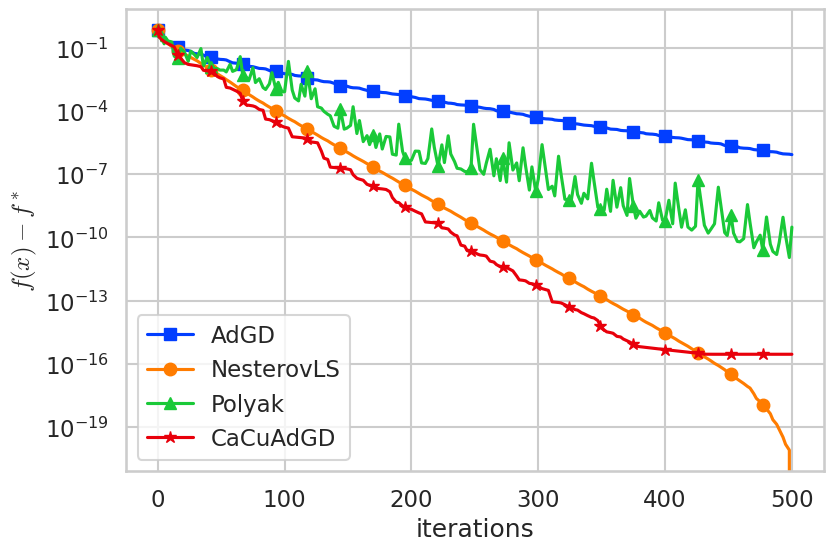

In [100]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(2.772122812435447e-18)
Running optimizer: AdGD


/home/nazarii.tupitsa/opt_methods/optmethods/first_order/adgd.py:31: RuntimeWarning: invalid value encountered in scalar divide
  L = self.loss.norm(self.grad-self.grad_old) / self.loss.norm(self.x-self.x_old)


CPU times: user 2 s, sys: 0 ns, total: 2 s
Wall time: 2 s
Running optimizer: NesterovLS


CPU times: user 2 s, sys: 1e+03 ns, total: 2 s
Wall time: 2 s
Running optimizer: Polyak
CPU times: user 2 s, sys: 0 ns, total: 2 s
Wall time: 2 s
Running optimizer: CaCuAdGD
CPU times: user 2 s, sys: 0 ns, total: 2 s
Wall time: 2 s


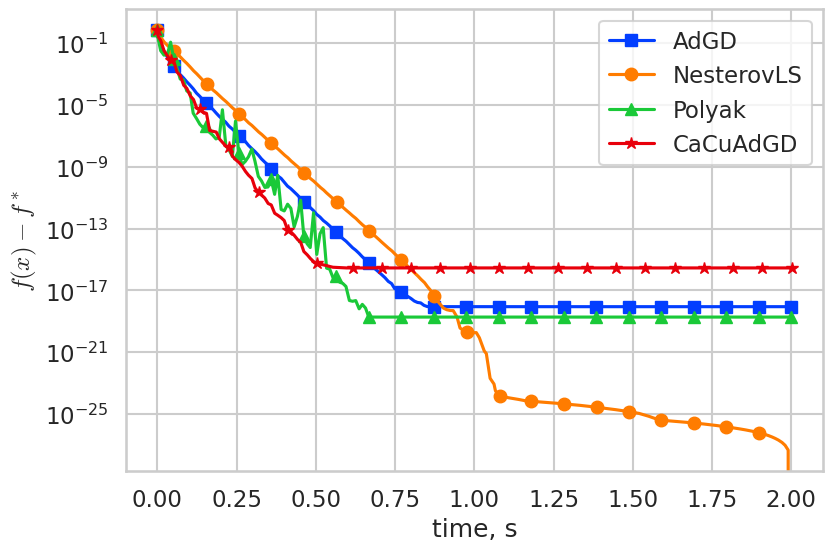

In [101]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=True
t_max = 2
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

## LogSumExp

In [145]:
n, dim = 2000, 1400
n, dim = 500, 200
least_squares_term = False
max_smoothing = 0.05
loss = LogSumExp(n=n, dim=dim, least_squares_term=least_squares_term, l2=l2, max_smoothing=max_smoothing)
# x0 = rng.normal(scale=0.5, size=dim)
x0 = np.ones(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)

fopt=np.float64(3.5676479024770744)


Running optimizer: AdGD
CPU times: user 892 ms, sys: 49.9 ms, total: 942 ms
Wall time: 890 ms
Running optimizer: NesterovLS
CPU times: user 3.43 s, sys: 50 ms, total: 3.48 s
Wall time: 3.42 s
Running optimizer: Polyak
CPU times: user 2 s, sys: 40 ms, total: 2.04 s
Wall time: 1.99 s
Running optimizer: CaCuAdGD
CPU times: user 3.89 s, sys: 40 ms, total: 3.93 s
Wall time: 3.85 s


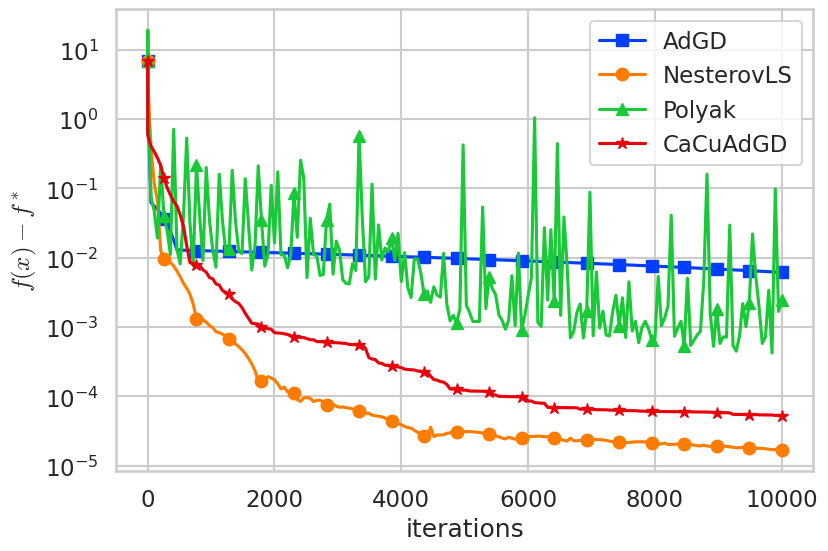

In [146]:
adgd = Adgd(loss=loss, label='AdGD')
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=False
it_max = 10000
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(3.5676479024770744)
Running optimizer: AdGD
CPU times: user 6.36 s, sys: 100 ms, total: 6.46 s
Wall time: 3 s
Running optimizer: NesterovLS
CPU times: user 3.01 s, sys: 20 ms, total: 3.03 s
Wall time: 3 s
Running optimizer: Polyak
CPU times: user 3 s, sys: 40 ms, total: 3.04 s
Wall time: 3 s
Running optimizer: CaCuAdGD
CPU times: user 3.01 s, sys: 30 ms, total: 3.04 s
Wall time: 3 s


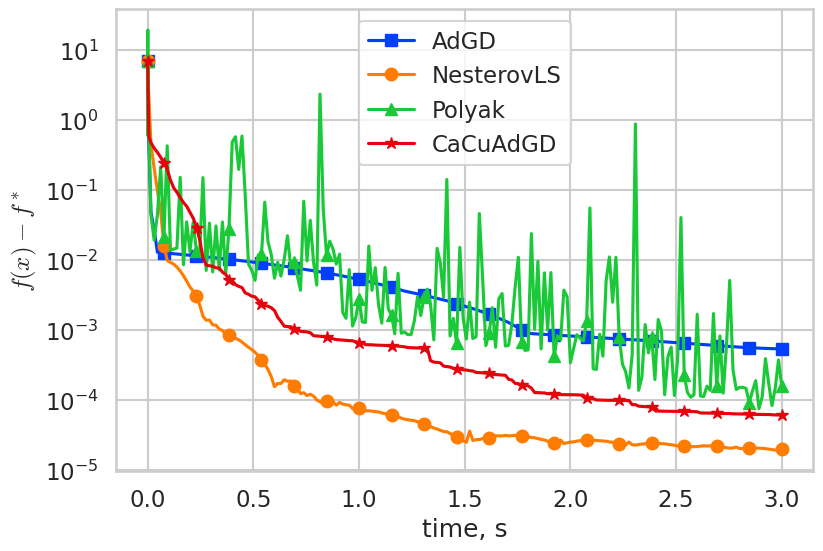

In [147]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
adgd = Adgd(loss=loss, label='AdGD')
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')

optimizers = [adgd, nest, pol, cacuadgd]

time=True
t_max = 3
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')